# Comparison of Spotify recommendation system using various techniques


In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly
from sklearn.preprocessing import StandardScaler
from scipy.spatial import distance
import copy
import warnings
warnings.filterwarnings("ignore")
plotly.offline.init_notebook_mode (connected = True)

In [116]:
data=pd.read_csv('spotify_genres_v2.csv')

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

In [118]:
data.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


In [119]:
df=copy.deepcopy(data)
df.drop(columns=[
    'type',
    'id',
    'uri',
    'track_href',
    'analysis_url',
    'duration_ms',
    'time_signature',
    'song_name',
    'Unnamed: 0',
    'title'
    ], 
inplace=True)

In [120]:
sns.set_theme(style="ticks", context="talk")
plt.style.use("dark_background")

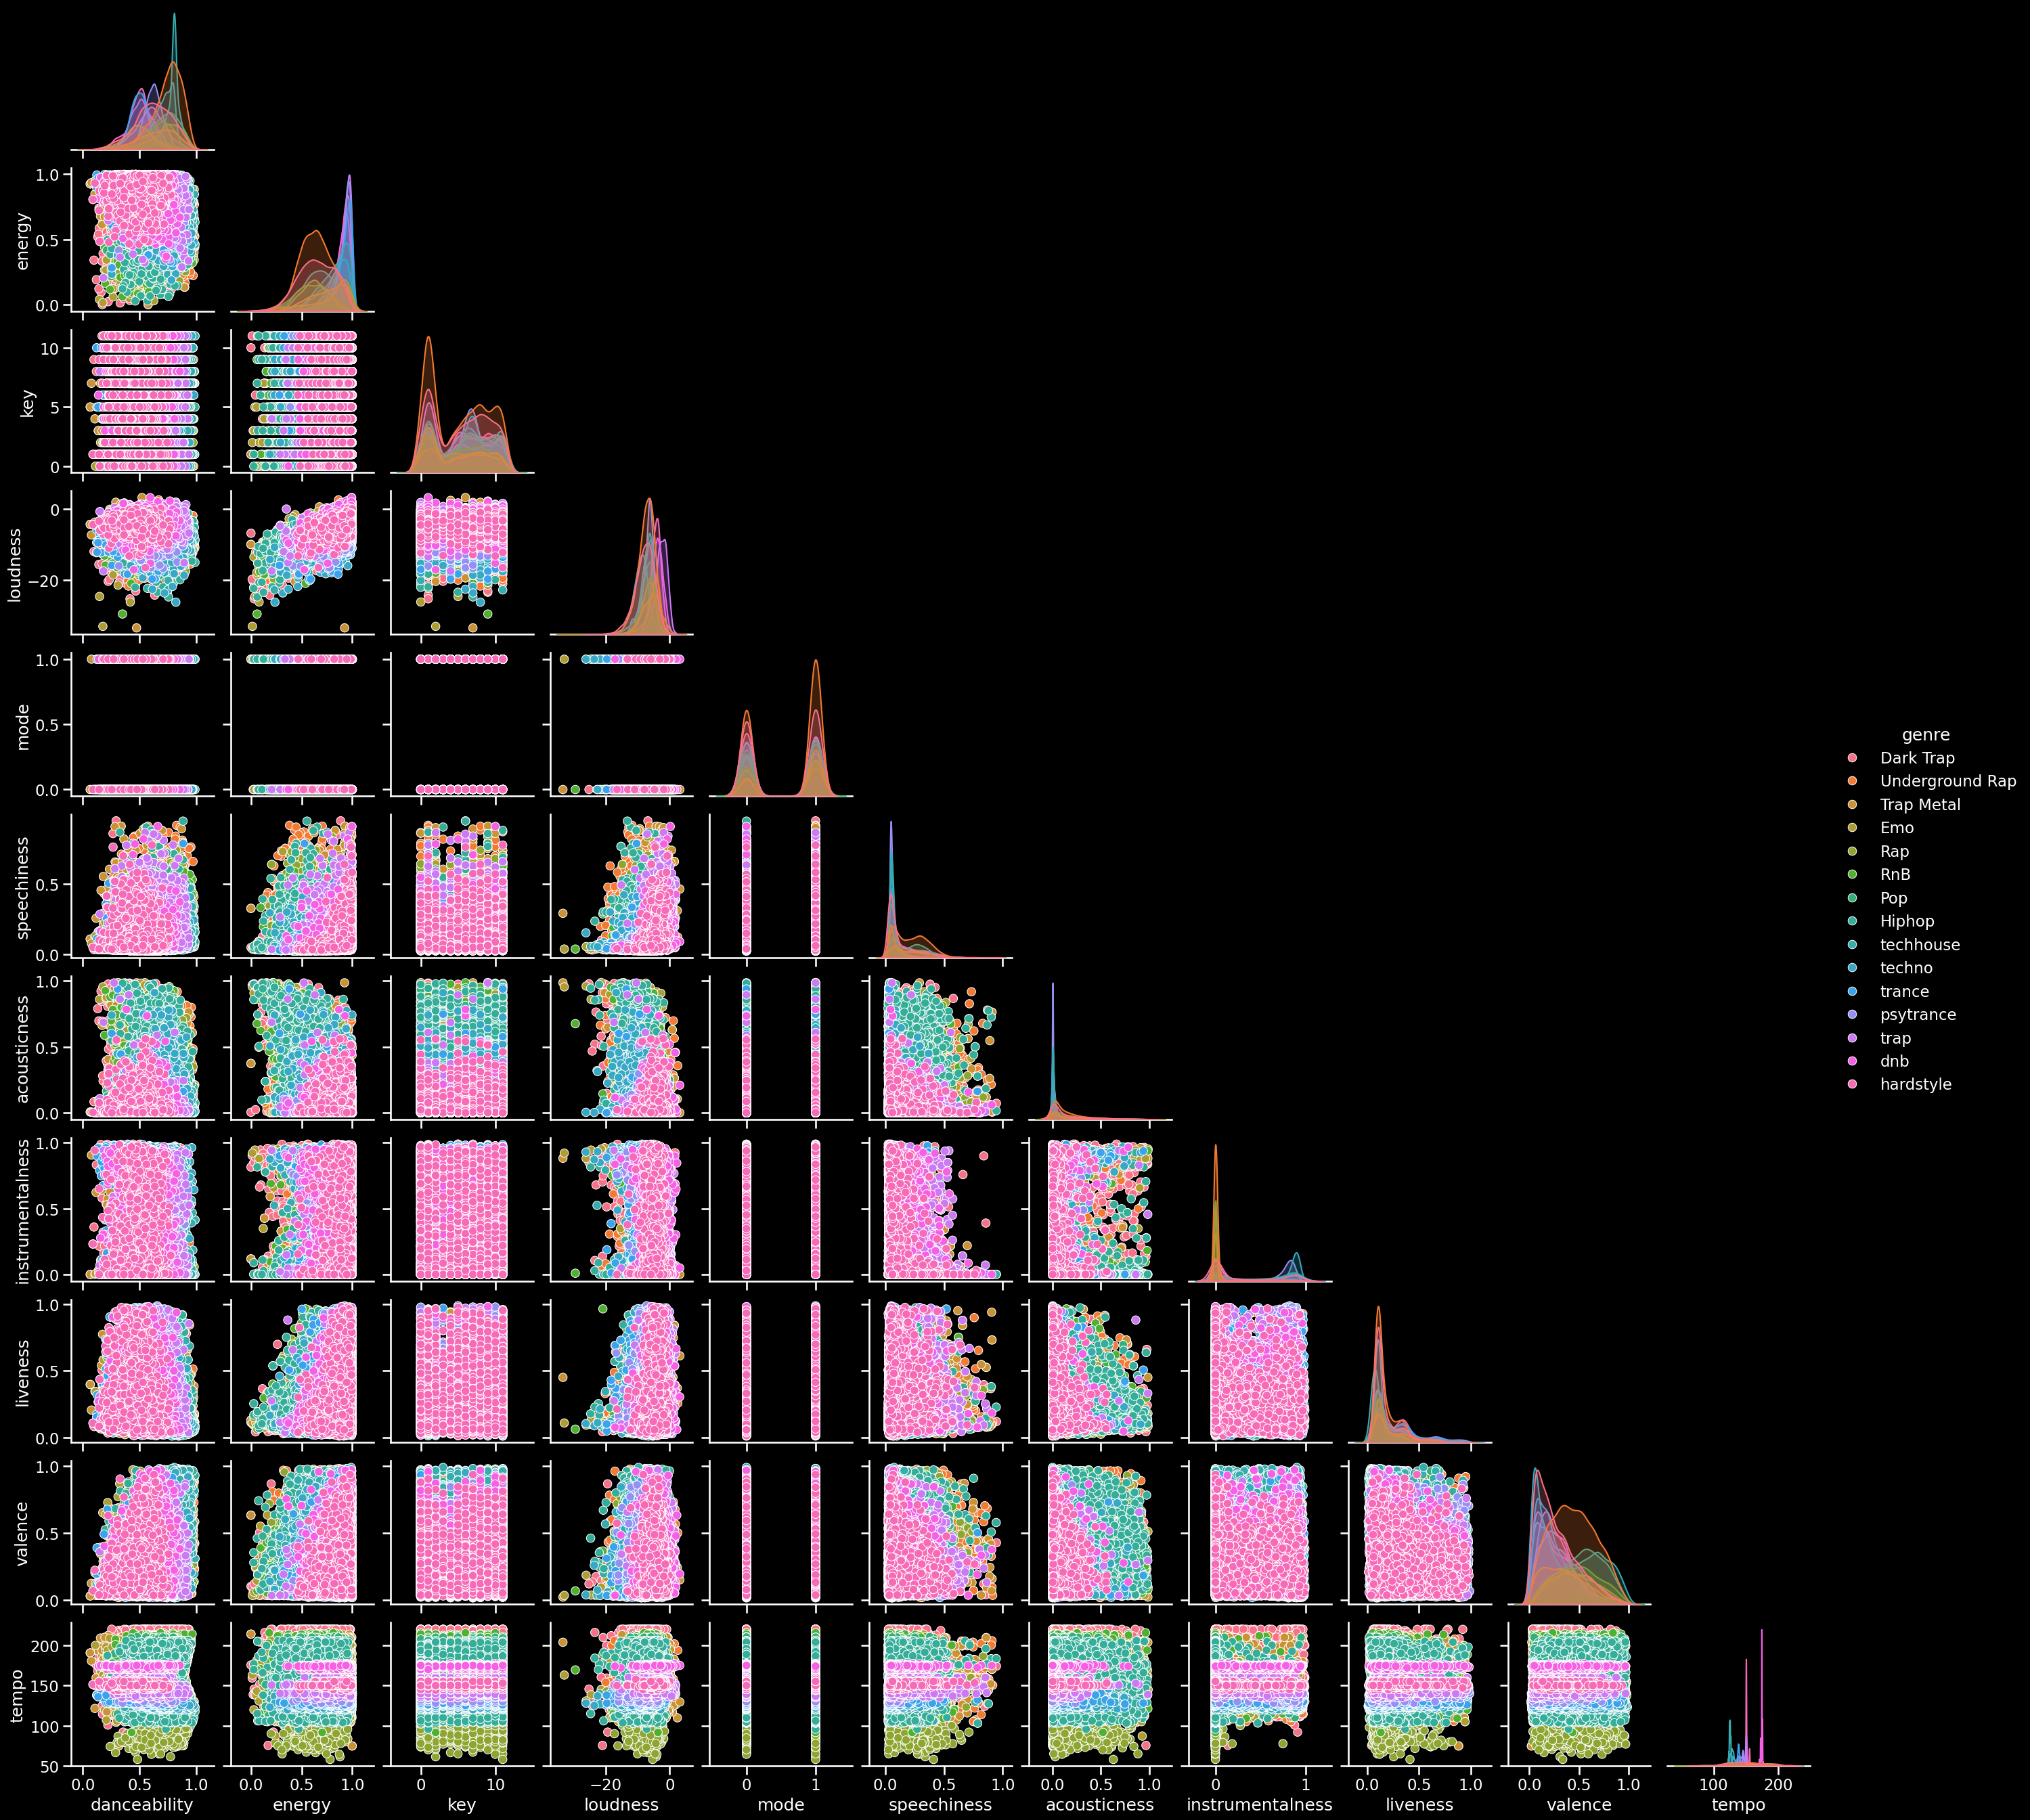

In [121]:
sns.pairplot(df,corner=True,hue='genre')

In [122]:
px.box(data_frame=data,y='duration_ms',color='genre')

In [123]:
data.drop('Unnamed: 0',axis=1,inplace=True)

In [124]:
x=list(data.select_dtypes("number").corr().columns)
y=list(data.select_dtypes("number").corr().index)
values=np.array(data.select_dtypes("number").corr().values)
fig = go.Figure(data=go.Heatmap(
    z=values,
    x=x,
    y=y,
    hoverongaps = False))
fig.show()

In [125]:
data.dropna(subset=['song_name'], inplace=True)

In [126]:
# Creating a new dataframe with required features
df_train = data[['danceability',
                 'energy',
                 'key',
                 'loudness',
                 'mode',
                 'speechiness',
                 'acousticness',
                 'instrumentalness',
                 'liveness',
                 'valence',
                 'tempo',
                 'genre',
                 'time_signature',
                 'duration_ms',
                 'song_name']]

In [127]:
x=df_train[df_train.drop(columns=['song_name','genre']).columns].values
scaler = StandardScaler().fit(x)
X_scaled = scaler.transform(x)
df_train[df_train.drop(columns=['song_name','genre']).columns]=X_scaled

In [128]:
# This is a function to find the closest song name from the list
def find_word(word,words):
    t=[]
    count=0
    if word[-1]==' ':
        word=word[:-1]
    for i in words:
        if word.lower() in i.lower():
            t.append([len(word)/len(i),count])
        else:
            t.append([0,count])
        count+=1
    t.sort(reverse=True)
    return words[t[0][1]]
        

In [129]:
# Making a weight matrix using euclidean distance
def make_matrix(data,song,number):
    df=pd.DataFrame()
    data.drop_duplicates(inplace=True)
    songs=data['song_name'].values
    song_result=find_word(song,songs)
    genre=data[data['song_name']==song_result]['genre'].values[0]
    df=data[data['genre']==genre]
    x=df[df['song_name']==song_result].drop(columns=['genre','song_name']).values
    if len(x)>1:
        x=x[1]
    if x.ndim > 1:
        x = x[0]
    song_names=df['song_name'].values
    df.drop(columns=['genre','song_name'],inplace=True)
    df=df.fillna(df.mean())
    p=[]
    count=0
    for i in df.values:
        p.append([distance.euclidean(x,i),count])
        count+=1
    p.sort()
    print(f'The song closest to your search {song} is :')
    for i in range(1,number+1):
        print(song_names[p[i][1]])

In [130]:
a=input('Please enter The name of the song :')
b=int(input('Please enter the number of recommendations you want: '))
make_matrix(df_train,a,b)

The song closest to your search CAN'T LOSE YOU is :
jealous traits
I LIKE BLOOD
i'd die for you
Alexis Turns 21
Mosh Pit


In [131]:
def make_matrix_cosine(data,song,number):
    df=pd.DataFrame()
    data.drop_duplicates(inplace=True)
    songs=data['song_name'].values
    song_result=find_word(song,songs)
    genre=data[data['song_name']==song_result]['genre'].values[0]
    df=data[data['genre']==genre]
    x=df[df['song_name']==song_result].drop(columns=['genre','song_name']).values
    if len(x)>1:
        x=x[1]
    if x.ndim > 1:
        x = x[0]
    song_names=df['song_name'].values
    df.drop(columns=['genre','song_name'],inplace=True)
    df=df.fillna(df.mean())
    p=[]
    count=0
    for i in df.values:
        p.append([distance.cosine(x,i),count])
        count+=1
    p.sort()
    print(f'The song closest to your {song} search is :')
    for i in range(1,number+1):
        print(song_names[p[i][1]])
    
    

In [132]:
c=input('Please enter The name of the song :')
d=int(input('Please enter the number of recommendations you want: '))
make_matrix_cosine(df_train, c,d)

The song closest to your CAN'T LOSE YOU search is :
jealous traits
Alexis Turns 21
I LIKE BLOOD
i'd die for you
Give It All Up


In [133]:
def make_matrix_correlation(data,song,number):
    df=pd.DataFrame()
    data.drop_duplicates(inplace=True)
    songs=data['song_name'].values
    song_result=find_word(song,songs)
    genre=data[data['song_name']==song_result]['genre'].values[0]
    df=data[data['genre']==genre]
    x=df[df['song_name']==song_result].drop(columns=['genre','song_name']).values
    if len(x)>1:
        x=x[1]
    if x.ndim > 1:
        x = x[0]
    song_names=df['song_name'].values
    df.drop(columns=['genre','song_name'],inplace=True)
    df=df.fillna(df.mean())
    p=[]
    count=0
    for i in df.values:
        p.append([distance.correlation(x,i),count])
        count+=1
    p.sort()
    print(f'The song closest to your search {song} is :')
    for i in range(1,number+1):
        print(song_names[p[i][1]])
    
    

In [134]:
e=input('Please enter The name of the song :')
f=int(input('Please enter the number of recommendations you want: '))
make_matrix_correlation(df_train, e,f)

The song closest to your search CAN'T LOSE YOU is :
jealous traits
i'd die for you
Alexis Turns 21
I LIKE BLOOD
30DayFreeTrial
